# Лабораторная работа №3 ОБУЧЕНИЕ С УЧИТЕЛЕМ. ЗАДАЧА КЛАССИФИКАЦИИ 

## Загрузка и подготовка данных

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold
from imblearn.over_sampling import SMOTE
from collections import Counter

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, RocCurveDisplay


RNG_SEED = 67
np.random.seed(seed=RNG_SEED)

### Загрузка датасета

In [48]:
df = pd.read_csv('../data/final_data_wine.csv')
df

,Unnamed: 0,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,0,0.164343,2.283475,-2.279442,-0.749952,1.238001,-1.133138,-1.467934,1.092436,1.808131,0.263930,-0.938658,5,1
1,1,0.477600,3.405904,-2.279442,-0.601255,2.344580,-0.322206,-0.876417,0.751612,-0.125112,1.160428,-0.603680,5,1
2,2,0.477600,2.657618,-1.988649,-0.664982,2.042786,-0.901443,-1.109439,0.819769,0.249064,0.936303,-0.603680,5,1
3,3,3.140279,-0.335528,1.791656,-0.749952,1.187702,-0.785596,-1.001890,1.160613,-0.374562,0.413346,-0.603680,6,1
4,4,0.164343,2.283475,-2.279442,-0.749952,1.238001,-1.133138,-1.467934,1.092436,1.808131,0.263930,-0.938658,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5969,4893,-0.775426,-0.772028,-0.171195,-0.813679,-0.623063,-0.380130,-0.428298,-1.177475,0.311427,-0.184319,0.568742,6,0
5970,4894,-0.462170,-0.086099,0.337693,0.545837,-0.220671,1.531351,0.933984,0.104033,-0.436925,-0.483152,-0.771169,5,0
5971,4895,-0.540484,-0.584956,-0.898176,-0.898649,-0.522465,-0.032588,-0.087728,-0.700317,-1.434728,-0.483152,-0.938658,6,0
5972,4896,-1.323625,-0.273170,-0.098496,-0.919892,-1.478147,-0.611825,-0.105652,-2.012500,0.747965,-1.080818,1.908654,7,0


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5974 entries, 0 to 5973
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            5974 non-null   int64  
 1   fixed acidity         5974 non-null   float64
 2   volatile acidity      5974 non-null   float64
 3   citric acid           5974 non-null   float64
 4   residual sugar        5974 non-null   float64
 5   chlorides             5974 non-null   float64
 6   free sulfur dioxide   5974 non-null   float64
 7   total sulfur dioxide  5974 non-null   float64
 8   density               5974 non-null   float64
 9   pH                    5974 non-null   float64
 10  sulphates             5974 non-null   float64
 11  alcohol               5974 non-null   float64
 12  quality               5974 non-null   int64  
 13  type                  5974 non-null   int64  
dtypes: float64(11), int64(3)
memory usage: 653.5 KB


### Выделеение целевого признака и предиктора, разделение на выборки

In [50]:
X = df.drop(columns=['type'])
y = df['type']
print(X.shape, y.shape)
print(y.value_counts())

(5974, 13) (5974,)
type
0    4575
1    1399
Name: count, dtype: int64


### Метод отложенной выборки hold-out (train/test)

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=67, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)


(4779, 13) (1195, 13)
(4779,) (1195,)


Задача бинарной классификации (2 признака 0,1 - белое и красное вино). В данных имеется явный дисбаланс классов - красного вина в 4 раза меньше белого

### Балансировка hold-out

In [52]:
oversample = SMOTE()
X_train_bal, y_train_bal = oversample.fit_resample(X_train, y_train)
# X_train_bal, y_train_bal = X_train, y_train


print(f'new train label count: {y_train_bal.value_counts()}')

new train label count: type
0    3660
1    3660
Name: count, dtype: int64


In [53]:
# Вспомогательная функция отображения таблицы
def format_cv_table(cv_results, model_name=None):
    metric_mapping = {
        'test_accuracy': 'Accuracy',
        'test_recall': 'Recall',
        'test_precision': 'Prec.',
        'test_f1': 'F1',
    }
    
    data = {'Fold': list(range(10))}
    
    for cv_key, col_name in metric_mapping.items():
        if cv_key in cv_results:
            data[col_name] = cv_results[cv_key]
    
    df = pd.DataFrame(data)
    df.set_index('Fold', inplace=True)
    
    mean_row = df.mean()
    std_row = df.std()
    
    df.loc['Mean'] = mean_row
    df.loc['Std'] = std_row
    df = df.round(4)
    
    print(f"Результаты 10-Fold CV для {model_name}:")
    
    display(df.style.apply(
        lambda row: ['background-color: yellow' if row.name == 'Mean' else '' for _ in row],
        axis=1
    ))

## Классификаторы

### Логистическая регрессия

In [54]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
logictic_regression = LogisticRegression(random_state=42, max_iter=1000)
cv_res = cross_validate(logictic_regression, X_train_bal, y_train_bal, 
                        cv=10, scoring=['f1','accuracy','precision','recall'])
format_cv_table(cv_res, model_name=logictic_regression)

Результаты 10-Fold CV для LogisticRegression(max_iter=1000, random_state=42):


,Accuracy,Recall,Prec.,F1
Fold,,,,
0,0.991800,0.989100,0.994500,0.991800
1,0.998600,0.997300,1.000000,0.998600
2,0.995900,0.991800,1.000000,0.995900
3,0.993200,0.994500,0.991800,0.993200
4,0.995900,0.994500,0.997300,0.995900
5,0.998600,1.000000,0.997300,0.998600
6,0.995900,0.994500,0.997300,0.995900
7,0.995900,1.000000,0.991900,0.995900
8,1.000000,1.000000,1.000000,1.000000


In [ ]:
logictic_regression.fit(X_train_bal, y_train_bal) 

y_pred_train = logictic_regression.predict(X_train)
y_pred_test = logictic_regression.predict(X_test)

accuracy_score(y_test, y_pred_train)
# confusion_matrix(y_test, y_pred)

NameError: name 'y_test_train' is not defined

In [56]:
print(logictic_regression)

LogisticRegression(max_iter=1000, random_state=42)


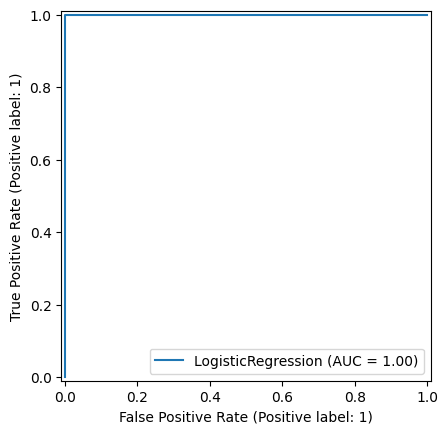

In [57]:
RocCurveDisplay.from_estimator(logictic_regression, X_test, y_pred)